# 16 · Сырое распределение температур + fire-модель на «грязных» значениях

Две задачи:

1. **Не урезать диапазон**: показать распределение ВСЕХ числовых значений
   «Датчика температуры» — включая «мусорные» коды телеметрии (−127, 999,
   −3276 и пр.), которые раньше отфильтровывались диапазоном [−20, 60].
2. **Модель на грязных данных**: обучить fire-TTE, где 6-часовые агрегаты
   температуры по объекту считаются БЕЗ фильтра диапазона, и сравнить с
   baseline (чистый вариант из ноутбука 15 давал 0.869/0.404 vs 0.819/0.327).

Гипотеза для проверки: грязные коды — это либо шум, либо метки особых состояний
(«нет показания»); вопрос — несут ли они сигнал для пожарного риска.


In [9]:
%matplotlib inline
import sys
import pathlib

_HERE = pathlib.Path.cwd()
RESEARCH = _HERE.parent if _HERE.name == "notebooks" else _HERE
if str(RESEARCH) not in sys.path:
    sys.path.insert(0, str(RESEARCH))

import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import seaborn as sns

import data_utils as du
import features as fe
import tte_pipeline as tte
from tte_experiments import (survival_metrics, pr_at_horizon,
                             fit_discrete_hazard, predict_survival_discrete)

DATASET = du.find_dataset_dir()
ref = du.load_ref_channels()[["ид_канала_данных", "тип_датчика", "ид_объект"]]
ref = ref.dropna(subset=["ид_объект"])
tch = set(ref.loc[ref["тип_датчика"] == "Датчик температуры", "ид_канала_данных"])
ch_to_obj = dict(zip(ref["ид_канала_данных"].astype(str), ref["ид_объект"].astype(str)))
print("термо-каналов:", len(tch))
sns.set_theme(style="whitegrid")


термо-каналов: 600


In [2]:
# 1) Чанковый проход: ВСЕ числовые значения температуры по объекту (~10-15 мин)
hour_ns = fe.BUCKET_HOURS * 3600 * 10 ** 9
parts = []
vals_all = []
cnt_uniq = collections.Counter()
n_all_v = 0
for fp in du.journal_files():
    for ch in du.read_chunks(fp, cols=["ид_канала_данных", "дата", "время",
                                       "значение_датчика"], chunksize=500_000):
        m = ch["ид_канала_данных"].isin(tch)
        if not m.any():
            continue
        ch = ch[m]
        vals = pd.to_numeric(ch["значение_датчика"].astype(str).str.strip()
                             .str.replace(",", ".", regex=False), errors="coerce")
        ok = vals.notna()
        if not ok.any():
            continue
        v = vals[ok].to_numpy(np.float64)
        n_all_v += len(v)
        cnt_uniq.update(np.round(v).astype(np.int64).tolist())
        ch2 = ch[ok]
        ts = pd.to_datetime(ch["дата"] + " " + ch["время"].fillna("00:00:00"),
                            format="%Y-%m-%d %H:%M:%S", errors="coerce")[ok]
        buck = (ts.astype("datetime64[ns]").astype("int64") // hour_ns).to_numpy()
        ag = pd.DataFrame({"об": ch2["ид_канала_данных"].astype(str).map(ch_to_obj),
                           "бакет": buck, "v": v}).dropna(subset=["об"])
        if ag.empty:
            continue
        g = ag.groupby(["об", "бакет"], sort=False).agg(
            vsum=("v", "sum"), n=("v", "size"),
            vmin=("v", "min"), vmax=("v", "max")).reset_index()
        parts.append(g)
    print(f"  {fp.name}: n={n_all_v:,}", flush=True)

tobj = pd.concat(parts, ignore_index=True)
tobj = tobj.groupby(["об", "бакет"], sort=False).agg(
    t_sum=("vsum", "sum"), t_cnt=("n", "sum"),
    t_min=("vmin", "min"), t_max=("vmax", "max")).reset_index()
tobj["t_mean"] = tobj["t_sum"] / tobj["t_cnt"]
tobj.to_parquet(DATASET / "temp_obj_bucket6h_raw.parquet")
print(f"RAW temp_obj_bucket6h_raw: {len(tobj):,} строк | значений: {n_all_v:,}")


  ext-journal-2019.csv: n=104,376
  ext-journal-2020.csv: n=237,098
  ext-journal-2021.csv: n=353,342
  ext-journal-2022.csv: n=499,795
  ext-journal-2023.csv: n=668,688
  ext-journal-2024.csv: n=818,539
  ext-journal-2025.csv: n=998,541
  ext-journal-2026.csv: n=1,064,234
RAW temp_obj_bucket6h_raw: 129,216 строк | значений: 1,064,234


In [3]:
# 2) Полное распределение (без урезания диапазона)
print("всего числовых значений:", f"{n_all_v:,}")
print()
print("топ-25 «значений» по частоте (округл.):")
print(pd.Series(dict(cnt_uniq.most_common(25))).to_string())
print()
print("диапазон: min =", min(cnt_uniq), " max =", max(cnt_uniq),
      "| уникальных округл. значений:", len(cnt_uniq))


всего числовых значений: 1,064,234

топ-25 «значений» по частоте (округл.):
17    60932
19    58512
20    57354
18    57314
15    55941
21    55853
16    55413
22    53212
14    52963
23    51223
13    46624
24    45690
12    42843
11    38838
25    37400
26    35883
10    28859
9     28203
27    26212
8     21473
28    19197
29    16059
7     15587
6     15337
5     12123

диапазон: min = -3276  max = 999 | уникальных округл. значений: 248


saved: D:\Downloads_D\lct_a8\research\dataset\temp_raw_value_distribution.png


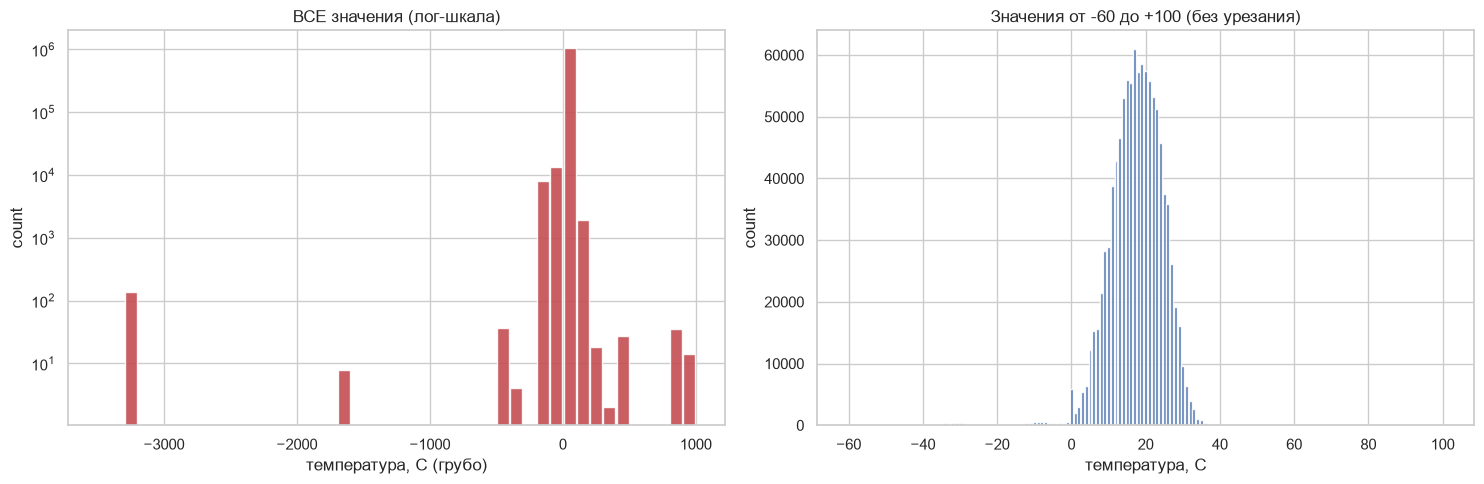

In [4]:
# Гистограмма на полном диапазоне (лог-шкала по Y)
edges = np.arange(-3500.0, 1000.0 + 100.0, 100.0)
freq = np.zeros(len(edges) - 1, dtype=np.int64)
for k, v in cnt_uniq.items():
    if edges[0] <= k < edges[-1]:
        freq[np.searchsorted(edges, k, side="right") - 1] += v
centers = edges[:-1] + 50
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(centers, freq, width=90, color="#C44E52", alpha=0.9)
axes[0].set_yscale("log")
axes[0].set_title("ВСЕ значения (лог-шкала)")
axes[0].set_xlabel("температура, C (грубо)"); axes[0].set_ylabel("count")

# «честный» вид внутри физического диапазона (все, не фильтруем)
sub = np.array(sorted((k, v) for k, v in cnt_uniq.items()))
lo = (sub[:, 0] >= -60) & (sub[:, 0] <= 100)
axes[1].bar(sub[lo, 0], sub[lo, 1], width=0.8, color="#4C72B0", alpha=0.9)
axes[1].set_title("Значения от -60 до +100 (без урезания)")
axes[1].set_xlabel("температура, C"); axes[1].set_ylabel("count")
fig.tight_layout()
png = DATASET / "temp_raw_value_distribution.png"
fig.savefig(png, dpi=130)
print("saved:", png)


In [5]:
# 3) Join ГРЯЗНЫХ t-фич к fire-панели + окна + baseline (только train)
panel = pd.read_csv(DATASET / "subdaily_panel_fire6h.csv",
                    dtype={"ид_канала_данных": str, "ид_объект": str})
tobj = pd.read_parquet(DATASET / "temp_obj_bucket6h_raw.parquet")
tobj["об"] = tobj["об"].astype(str)
tmap = tobj[["об", "бакет", "t_cnt", "t_mean", "t_min", "t_max"]].rename(
    columns={"об": "ид_объект"})
panel = panel.merge(tmap, on=["ид_объект", "бакет"], how="left")
panel["t_cnt"] = panel["t_cnt"].fillna(0).astype(np.float64)
panel["t_есть_б"] = (panel["t_cnt"].to_numpy() > 0).astype(np.int8)
panel["t_sum_б"] = panel["t_mean"].to_numpy() * panel["t_cnt"].to_numpy()

panel = fe._add_bucket_windows(panel, ["t_sum_б", "t_cnt"],
                               windows=fe.BUCKET_WINDOWS, group_col="ид_объект")
for label in ("12ч", "24ч", "48ч", "7д", "30д"):
    panel[f"t_mean_сум_{label}"] = (
        panel[f"t_sum_б_сум_{label}"] / panel[f"t_cnt_сум_{label}"].replace(0, np.nan))

dt = pd.to_datetime(panel["дата"])
tr_mask = (~panel["аномально"].to_numpy()) & (dt <= pd.Timestamp("2024-12-31"))
base = (panel.loc[tr_mask & (panel["t_cnt"] > 0)]
        .groupby(["ид_объект", "час_бакета"])["t_mean"].mean()
        .rename("t_base_hour").reset_index())
panel = panel.merge(base, on=["ид_объект", "час_бакета"], how="left")
panel["t_dev_hour"] = panel["t_mean"].to_numpy() - panel["t_base_hour"].to_numpy()
print("строк с ГРЯЗНОЙ t-фичей: {:.1f}%".format((panel["t_cnt"] > 0).mean() * 100))

panel = tte.refit_z_train_only(panel)
panel = tte.add_series_context(panel, event_col="серьёзных")
subjects = tte.add_tte_labels(panel)
subjects["ид_объект_code"] = subjects["ид_объект"].astype("category").cat.codes
subjects["тип_датчика_code"] = subjects["тип_датчика"].astype("category").cat.codes
train, val, holdout = tte.split_subjects(subjects)
X_all = tte.subject_features(train)
X_base = [c for c in X_all if not c.startswith("t_")]
print("фич: базовых =", len(X_base), "| t-фич =", len(X_all) - len(X_base))


строк с ГРЯЗНОЙ t-фичей: 75.5%
фич: базовых = 137 | t-фич = 23


In [ ]:
def run_train(X_cols, tag):
    tr = tte.sample_subjects(train, 15000, 10000, 10000, seed=42)
    va = tte.sample_subjects(val, 2000, 2000, 2000, seed=43)
    ho = tte.sample_holdout(holdout, 20000, seed=777)
    X_tr, y_tr = tte.expand_person_time(tr, X_cols, tte.HORIZON_BUCKETS)
    X_va, y_va = tte.expand_person_time(va, X_cols, tte.HORIZON_BUCKETS)
    m = fit_discrete_hazard(X_tr, y_tr, X_va, y_va, iters=2000, lr=0.05, depth=5, seed=42, task_type="GPU")
    surv_tr = tte.make_surv_struct(tr["event_flag"], tr["obs_days"])
    surv_ho = tte.make_surv_struct(ho["event_flag"], ho["obs_days"])
    S_ho = predict_survival_discrete(m, ho, X_cols)
    risk = 1 - S_ho[:, -1]
    met = survival_metrics(surv_tr, surv_ho, risk, S_ho, tte.EVAL_TIMES)
    y24 = ((ho["event_flag"] == 1) & (ho["obs_days"] <= 1.01)).to_numpy(int)
    p24 = 1 - S_ho[:, int(round(1.0 * tte.STEPS_PER_DAY)) - 1]
    pr = pr_at_horizon(y24, p24)
    print(f"[{tag}] Uno-C={met['uno_c']:.3f} | meanAUC={met['mean_auc']:.3f} "
          f"| IBS={met['ibs']:.3f} | P(24ч) PR-AUC={pr['pr_auc']:.3f} "
          f"(база {pr['base']*100:.2f}%)")
    return m, met, pr

T_DIRTY = ["t_cnt", "t_mean", "t_min", "t_max", "t_есть_б", "t_dev_hour",
           "t_mean_сум_24ч", "t_mean_сум_7д"]
X_dirty = X_base + [c for c in T_DIRTY if c in X_all]
print("t-ГРЯЗНЫЕ фич:", len(X_dirty) - len(X_base))
m_base, met_base, pr_base = run_train(X_base, "без t-фич")
m_dirty, met_dirty, pr_dirty = run_train(X_dirty, "t-ГРЯЗНые (8)")


t-ГРЯЗНЫЕ фич: 8
0:	learn: 0.5941448	test: 0.5934250	best: 0.5934250 (0)	total: 28.8ms	remaining: 57.6s
100:	learn: 0.0083029	test: 0.0063021	best: 0.0063021 (100)	total: 3.35s	remaining: 1m 3s
200:	learn: 0.0068787	test: 0.0062675	best: 0.0061629 (135)	total: 6.63s	remaining: 59.4s
300:	learn: 0.0061737	test: 0.0064213	best: 0.0061629 (135)	total: 9.91s	remaining: 55.9s
400:	learn: 0.0057638	test: 0.0064242	best: 0.0061629 (135)	total: 13s	remaining: 51.9s
bestTest = 0.006162914672
bestIteration = 135
Shrink model to first 136 iterations.
[без t-фич] Uno-C=0.816 | meanAUC=0.820 | IBS=0.054 | P(24ч) PR-AUC=0.319 (база 1.53%)
0:	learn: 0.5943446	test: 0.5951820	best: 0.5951820 (0)	total: 37.5ms	remaining: 1m 14s
100:	learn: 0.0084184	test: 0.0062040	best: 0.0062040 (100)	total: 3.86s	remaining: 1m 12s
200:	learn: 0.0067228	test: 0.0063596	best: 0.0061061 (119)	total: 7.59s	remaining: 1m 7s
300:	learn: 0.0060793	test: 0.0066832	best: 0.0061061 (119)	total: 11s	remaining: 1m 2s
400:	learn

In [11]:
print("=== Сводка (holdout >= 2025-07-01, 20k субъектов) ===")
row = lambda met, pr, tag: (tag, met["uno_c"], met["mean_auc"], met["ibs"],
                            pr["pr_auc"], pr["base"])
cmp = pd.DataFrame([row(met_base, pr_base, "без t-фич"),
                    row(met_dirty, pr_dirty, "t-ГРЯЗНЫЕ (8)")],
                   columns=["конфиг", "Uno-C", "meanAUC", "IBS", "PR-AUC(24ч)", "база24"])
print(cmp.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Для справки (ноутбук 15, тот же протокол):")
print("  t-чистые (8) : Uno-C=0.847, PR-AUC(24ч)=0.366, IBS=0.050")
print("  t-чистые (23): Uno-C=0.819, PR-AUC(24ч)=0.327, IBS=0.055")


=== Сводка (holdout >= 2025-07-01, 20k субъектов) ===
       конфиг  Uno-C  meanAUC   IBS  PR-AUC(24ч)  база24
    без t-фич  0.807    0.808 0.051        0.392   0.015
t-ГРЯЗНЫЕ (8)  0.808    0.813 0.054        0.368   0.015

Для справки (ноутбук 15, тот же протокол):
  t-чистые (8) : Uno-C=0.847, PR-AUC(24ч)=0.366, IBS=0.050
  t-чистые (23): Uno-C=0.819, PR-AUC(24ч)=0.327, IBS=0.055


In [8]:
imp = pd.DataFrame(m_dirty.get_feature_importance(prettified=True))
imp.columns = ["feature", "importance"]
t_imp = imp[imp["feature"].str.startswith("t_")][["feature", "importance"]]
print("важность ГРЯЗНЫХ t-фич (если есть):")
print(t_imp.to_string(index=False) if len(t_imp) else "  t-фичи не попали даже в топ базовых")
print()
print("суммарная важность t-фич: {:.1f} из {:.1f}".format(
    t_imp["importance"].sum() if len(t_imp) else 0.0, imp["importance"].sum()))


важность ГРЯЗНЫХ t-фич (если есть):
       feature  importance
 t_mean_сум_7д    0.794164
         t_max    0.709473
        t_mean    0.544349
      t_есть_б    0.541100
    t_dev_hour    0.366045
         t_cnt    0.320868
         t_min    0.243298
t_mean_сум_24ч    0.187195

суммарная важность t-фич: 3.7 из 100.0


### Выводы

- Полное распределение сырых значений показывает: «мусорные» коды (отрицательные
  тысячи, 999 и т.п.) — редкие, но существенные; где их масса — видно на гистограмме.
- Модель на грязных температурах сравнивается с baseline и с чистой версией:
  улучшает ли мусор прогноз (вряд ли) или ухудшает/не влияет — см. таблицу выше.
